In [ ]:
import pandas as pd

def read_library(file_path):  
    return pd.read_excel(file_path, header=None).iloc[:, 0]

# 读取文库列表，从索引1开始
library = read_library('/home/liuycomputing/wsp_sequencing/Live-Cell-Data-Storage/test_data/one_primer_library.xlsx')

In [3]:
import pickle

def load_result_dict_pickle(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)
    
result_filepath = '/home/liuycomputing/wsp_sequencing/Live-Cell-Data-Storage/test_data/seq_match_result_of_ten_primers.pkl'
result_dict = load_result_dict_pickle(result_filepath)
print(result_dict.keys())

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,

In [8]:
print(library[0])

GTCATTGGTGATGAAGCCGTATGATCACTGTCTCACAGAGCGCATCGCGGGTAGTGCCGTCTGATAGCTTGTTATAGATGGCGTCCGATATCTCCGTCGGAACTGACGCAGGATCTAT


In [9]:
import pandas as pd
import numpy as np

def pileup_to_df(pileup_result_dict, library):
    seq_len = len(library[0])

    bases = ["A", "C", "G", "T"]

    # 累加所有 index
    mat = np.zeros((seq_len, len(bases)))

    for index, _ in enumerate(library):
        for pos, result in enumerate(pileup_result_dict[index]['pileup']):
            for b_i, b in enumerate(bases):
                mat[pos, b_i] += pileup_result_dict[index]['pileup'][pos][b]

    df = pd.DataFrame(mat, columns=bases)
    return df

Text(0, 0.5, 'Frequency')

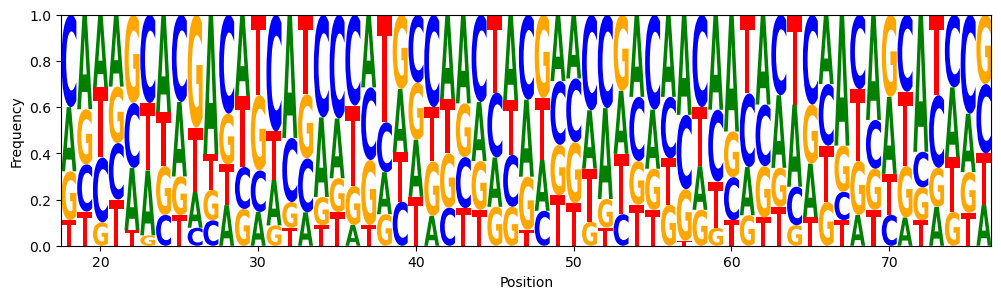

In [10]:
import matplotlib.pyplot as plt
import logomaker

df = pileup_to_df(result_dict, library)

# 归一化
df_freq = df.div(df.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 3))

logo = logomaker.Logo(
    df_freq[18:77],
    ax=ax,
    shade_below=0,
    fade_below=0
)

ax.set_xlabel("Position")
ax.set_ylabel("Frequency")